# Simulation based inference on the trajectories for the 2D parameter space

I use my own `conda` environment with `torch` and `lampe`. Data is downloaded from Zenodo and stored in the `data` directory. The data is not included in the repository, but can be downloaded from the Zenodo link provided in the README.

In [1]:
import lampe
from tqdm import tqdm

## Read training data

I use the information in the `lampe` tutorial about data and simulators: [https://lampe.readthedocs.io/stable/tutorials/simulators.html](https://lampe.readthedocs.io/stable/tutorials/simulators.html)

In [13]:
import numpy as np

# Load data from numpy files
params = np.load('../data/training-trajectories/2D-delta-omega/param_rand_list-2D.npy')
taus = np.load('../data/training-trajectories/2D-delta-omega/taus-2D.npy')


The `params` have been generated from a uniform prior distribution and the `taus` are generated by a simulator that solves the Master Equation of the TLS and returns single trajectories with jumps.

In [14]:
print(f"We have {len(params)} trajectories")

We have 4000000 trajectories


In [15]:
params.shape

(4000000, 2)

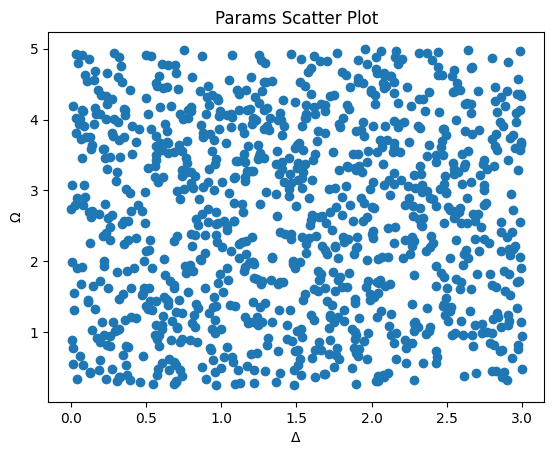

In [52]:
import matplotlib.pyplot as plt

params_2d = params[:1000]  # Select the first 1000 points

LABELS = [r'$\Delta$', r'$\Omega$']
plt.scatter(params_2d[:, 0], params_2d[:, 1])
plt.xlabel(LABELS[0])
plt.ylabel(LABELS[1])
plt.title('Params Scatter Plot')
plt.show()

We can save the training data in a HDF5 file for convenience. We use the `lampe.data.H5Dataset` class to store the data

In [16]:
pairs = []
batch_size = 512
batch_num = 1000  # test on just 1000 batches
training_size = batch_size*batch_num

for i in range(batch_num):
    theta = params[i*batch_size:(i+1)*batch_size]
    x = taus[i*batch_size:(i+1)*batch_size]

    pairs.append((theta, x))

lampe.data.H5Dataset.store(pairs, "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5", size=training_size)

100%|██████████| 512000/512000 [00:00<00:00, 1569301.27pair/s]


The saved data can be loaded using the `lampe.data.H5Dataset` class.

In [17]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5"
)

In [18]:
for theta, x in tqdm(dataset):
    pass

100%|██████████| 512000/512000 [00:02<00:00, 246360.56it/s]


Can batch and shuffle

In [19]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5",
    batch_size=4,
    shuffle=True,
)

In [20]:
for theta, x in dataset:
    print(theta, x, sep="\n")
    break

tensor([[2.3165, 1.4247],
        [2.1748, 0.4196],
        [1.1790, 1.9139],
        [2.6648, 4.5129]])
tensor([[ 0.8448,  7.7672,  1.4842,  2.0511,  0.6310,  1.0969,  0.3215,  2.0967,
          2.1123,  0.8325,  0.3472,  1.0268,  5.2264,  0.5361,  0.7962,  3.9089,
          0.2453,  0.7965,  2.9339,  0.5270,  2.1813, 13.8362,  0.6326,  7.6198,
          5.9897,  4.3091, 11.8323,  3.1943,  1.4028,  0.9067,  1.2204,  0.2917,
          0.3792,  5.8998,  7.2342,  2.6146,  0.5027, 14.8837,  5.8206,  1.0191,
          0.8182,  9.8859,  2.1853,  2.4798,  0.4147,  0.3145,  4.0731,  4.8064],
        [ 4.9519, 30.5859,  8.8833, 33.1919, 55.4896, 68.2288, 22.0889, 61.5484,
         14.5012, 39.9060, 11.6391, 36.1273, 28.6280, 24.0600, 14.2459, 99.8895,
          3.3961, 28.9693, 46.1978, 19.6244,  7.4502, 21.2540, 31.1112, 45.2022,
         20.4902,  7.5647,  5.1424, 20.9375,  5.3178, 16.2526, 13.7885, 32.8369,
          5.5690, 21.7863, 36.0042,  4.0137,  1.3316, 10.4478,  5.9273, 24.6332,
   

## Train NPE

For training, we shuffle the data and use a batch size of 256. We also load everything in memory for simplicity.

In [25]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5", batch_size=256, shuffle=True
).to_memory()

In [26]:
type(dataset)

lampe.data.JointDataset

In [45]:
dataset[0][0].dtype

torch.float32

Training a NPE model is done by following this tutorial on the `lampe` documentation: [https://lampe.readthedocs.io/stable/tutorials/npe.html#training](https://lampe.readthedocs.io/stable/tutorials/npe.html#training)

In [27]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import zuko

from itertools import islice
from lampe.data import JointLoader
from lampe.inference import NPE, NPELoss
from lampe.plots import corner, mark_point, nice_rc
from lampe.utils import GDStep
from tqdm import trange

In [29]:
# shape of parameters and trajectories
theta_dim = params.shape[-1]
x_dim = taus.shape[-1]

# create estimator object for the posterior
estimator = NPE(theta_dim=theta_dim, x_dim=x_dim, transforms=3, hidden_features=[64] * 3)
estimator

NPE(
  (flow): MAF(
    (transform): LazyComposedTransform(
      (0): MaskedAutoregressiveTransform(
        (base): MonotonicAffineTransform()
        (order): [0, 1]
        (hyper): MaskedMLP(
          (0): MaskedLinear(in_features=50, out_features=64, bias=True)
          (1): ReLU()
          (2): MaskedLinear(in_features=64, out_features=64, bias=True)
          (3): ReLU()
          (4): MaskedLinear(in_features=64, out_features=64, bias=True)
          (5): ReLU()
          (6): MaskedLinear(in_features=64, out_features=4, bias=True)
        )
      )
      (1): MaskedAutoregressiveTransform(
        (base): MonotonicAffineTransform()
        (order): [1, 0]
        (hyper): MaskedMLP(
          (0): MaskedLinear(in_features=50, out_features=64, bias=True)
          (1): ReLU()
          (2): MaskedLinear(in_features=64, out_features=64, bias=True)
          (3): ReLU()
          (4): MaskedLinear(in_features=64, out_features=64, bias=True)
          (5): ReLU()
          (6)

The default builder for the NPE is a Masked Autoregressive Flow (MAF)

In the case of NPE, the loss to minimize is the expected negative log-likelihood of the data 

In [30]:
loss = NPELoss(estimator)

In [33]:
loss(*dataset[0])

tensor(9.2796, grad_fn=<NegBackward0>)

Training loop

In [35]:
optimizer = optim.Adam(estimator.parameters(), lr=1e-3)
step = GDStep(optimizer, clip=1.0)  # gradient descent step with gradient clipping

estimator.train()

for epoch in (bar := trange(10, unit="epoch")):
    losses = []

    for theta, x in dataset:
        losses.append(step(loss(theta, x)))

    bar.set_postfix(loss=torch.stack(losses).mean().item())

100%|██████████| 10/10 [00:55<00:00,  5.52s/epoch, loss=1.3]


# Quick evaluation

We take a datapoint from the training data that has not actually been used for training (it was not saved on the HDF5 file) and evaluate the NPE model on it.

In [46]:
theta_star = torch.tensor(params[1_000_000], dtype=torch.float32)
x_star = torch.tensor(taus[1_000_000], dtype=torch.float32)

Sample from the posterior. It is a flow-based model, and we condition it on the observation `x_star`

In [49]:
estimator.eval()

with torch.no_grad():
    samples = estimator.flow(x_star).sample((2**16,))

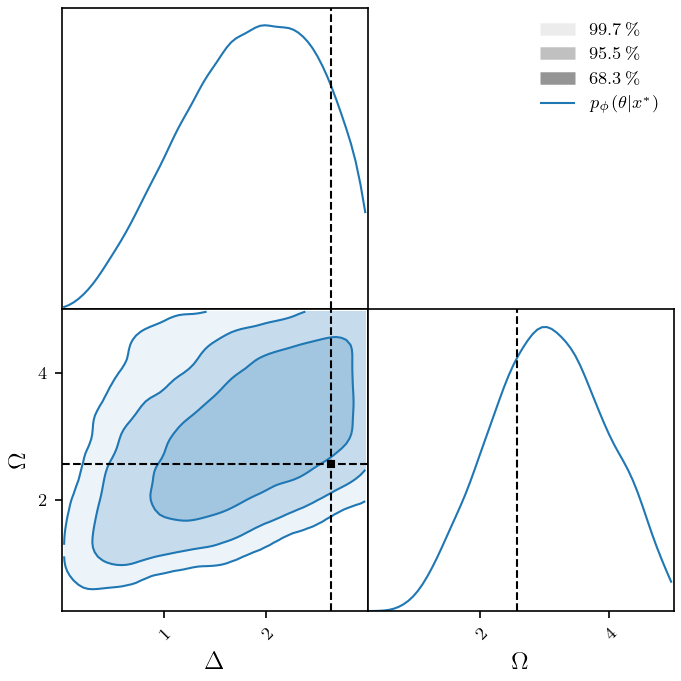

In [53]:
plt.rcParams.update(nice_rc(latex=True))  # nicer plot settings

LOWER = torch.tensor([0.0, 0.25])
UPPER = torch.tensor([3.0, 5.0])
LABELS = [r"$\Delta$", r"$\Omega$"]

fig = corner(
    samples,
    smooth=2,
    domain=(LOWER, UPPER),
    labels=LABELS,
    legend=r"$p_\phi(\theta | x^*)$",
    figsize=(4.8, 4.8),
)

mark_point(fig, theta_star)